####  EXPLORATORY DATA ANALYSIS 

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/Crop_recommendation.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB


In [4]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [5]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [6]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [7]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

In [8]:
df.shape

(2200, 8)

In [9]:
df.head(10)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [10]:
df['label'].unique()

<ArrowStringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str

Handling missing data + outliers

In [11]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [12]:
(df == 0).sum()

N              27
P               0
K               0
temperature     0
humidity        0
ph              0
rainfall        0
label           0
dtype: int64

In [13]:
df[df['N'] == 0]['label'].value_counts()

label
lentil         4
orange         4
coconut        4
pomegranate    3
mango          3
apple          3
kidneybeans    2
pigeonpeas     1
mothbeans      1
mungbean       1
grapes         1
Name: count, dtype: int64

In [14]:
df = df[df['N']!=0]

In [15]:
print(2200 - len(df))

27


In [16]:
(df == 0).sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [17]:
Q1 = df['N'].quantile(0.25)

In [18]:
Q3 = df['N'].quantile(0.75)

In [19]:
IQR = Q3-Q1

In [20]:
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

In [21]:
df_clean = df[(df['N'] >= lower) & (df['N'] <= upper)]

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

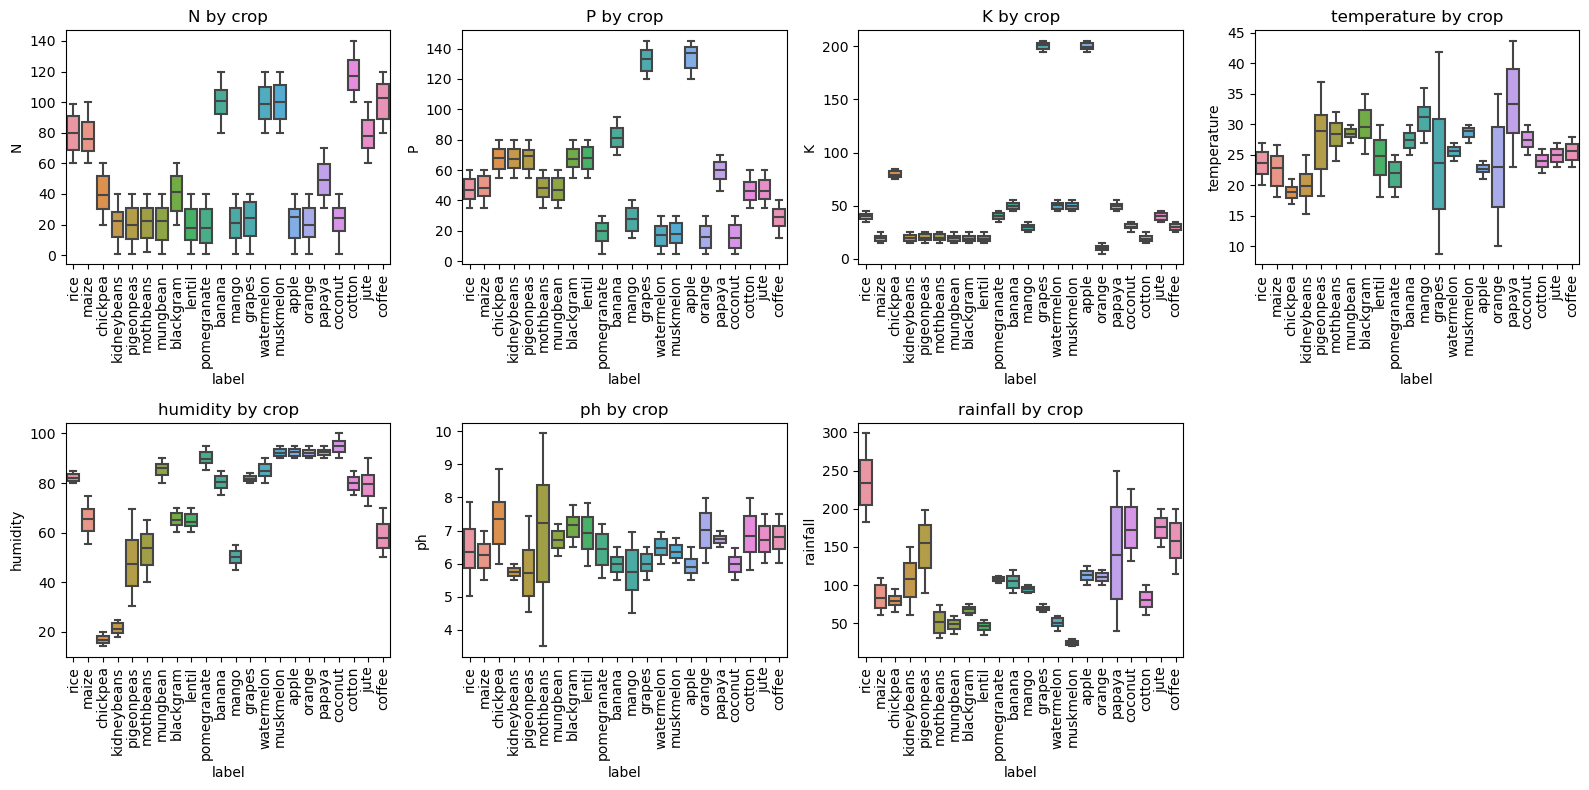

In [23]:
features = ['N','P','K','temperature','humidity','ph','rainfall']

fig, axes = plt.subplots(2,4, figsize=(16,8))
axes = axes.flatten()

for i,cols in enumerate(features):
    sns.boxplot(data = df, x='label', y=cols, ax=axes[i])
    axes[i].set_title(f'{cols} by crop')
    axes[i].tick_params(axis='x',rotation=90)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/boxplots.png', dpi=150)
plt.show()

Feature engineering - label encoding, scaling, test_train_split

In [24]:
from sklearn.preprocessing import LabelEncoder

In [25]:
LE = LabelEncoder()
df['crop_encoded'] = LE.fit_transform(df['label'])

In [26]:
mapping = dict(zip(LE.classes_, LE.transform(LE.classes_)))
print(mapping)

{'apple': 0, 'banana': 1, 'blackgram': 2, 'chickpea': 3, 'coconut': 4, 'coffee': 5, 'cotton': 6, 'grapes': 7, 'jute': 8, 'kidneybeans': 9, 'lentil': 10, 'maize': 11, 'mango': 12, 'mothbeans': 13, 'mungbean': 14, 'muskmelon': 15, 'orange': 16, 'papaya': 17, 'pigeonpeas': 18, 'pomegranate': 19, 'rice': 20, 'watermelon': 21}


In [27]:
import joblib

joblib.dump(LE, '../models/label_encoder.pkl')
print("saved label encoder")

saved label encoder


must save LE with joblib.dump because when your fastapi endpoint predicts 2, it needs the encoder to turn that back into 'blackgram'. if you dont save it, you will have to retrain just to decode outputs.

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
feature_cols =  ['N','P','K','temperature','humidity','ph','rainfall']

X= df[feature_cols].values
y = df['crop_encoded'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train size: {X_train_raw.shape}')
print(f"test_size: {X_test_raw.shape}")


Train size: (1738, 7)
test_size: (435, 7)


In [30]:
#verify stratification
import numpy as np
unique, train_counts = np.unique(y_train, return_counts=True)
_, test_counts= np.unique(y_test, return_counts=True)
for i, crop in enumerate(LE.classes_):
    print(f"{crop:15s} train:{train_counts[i]:4d} test: {test_counts[i]:3d}")

apple           train:  78 test:  19
banana          train:  80 test:  20
blackgram       train:  80 test:  20
chickpea        train:  80 test:  20
coconut         train:  77 test:  19
coffee          train:  80 test:  20
cotton          train:  80 test:  20
grapes          train:  79 test:  20
jute            train:  80 test:  20
kidneybeans     train:  78 test:  20
lentil          train:  77 test:  19
maize           train:  80 test:  20
mango           train:  78 test:  19
mothbeans       train:  79 test:  20
mungbean        train:  79 test:  20
muskmelon       train:  80 test:  20
orange          train:  77 test:  19
papaya          train:  80 test:  20
pigeonpeas      train:  79 test:  20
pomegranate     train:  77 test:  20
rice            train:  80 test:  20
watermelon      train:  80 test:  20


In [31]:
from sklearn.preprocessing import StandardScaler


In [32]:

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train_raw)
X_test_sc = scaler.transform(X_test_raw)

print("means:", X_train_sc.mean(axis=0).round(3))

print("stds:", X_train_sc.std(axis=0).round(3) )

joblib.dump(scaler, '../models/scaler.pkl')
print("saved scaler")

means: [-0.  0. -0. -0. -0. -0.  0.]
stds: [1. 1. 1. 1. 1. 1. 1.]
saved scaler


Visualisations

In [33]:
import seaborn as sns

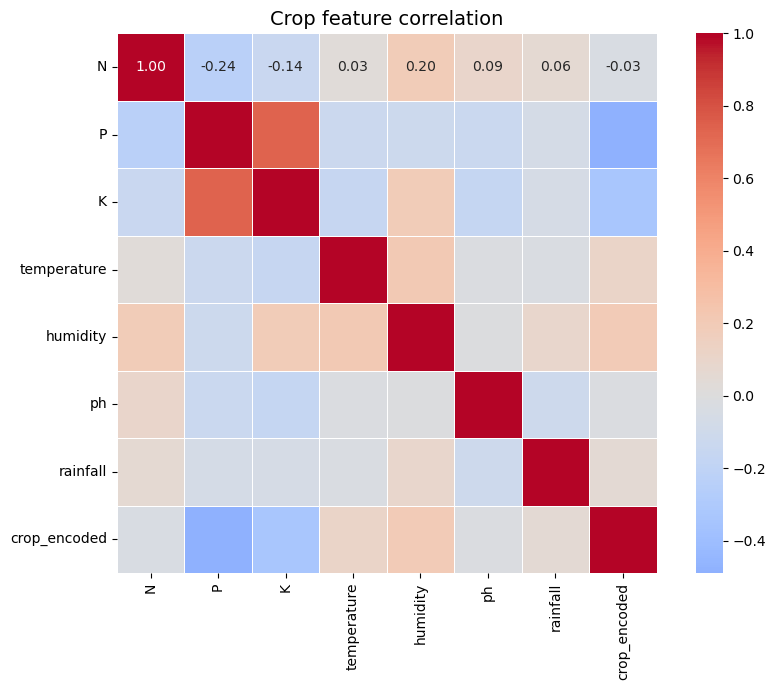

In [34]:
plt.figure(figsize=(9,7))
numeric_df = df.drop(columns=['label'])
corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt ='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Crop feature correlation', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/heatmap.png',dpi=150)
plt.show()

Histogram for feature distribution per crop

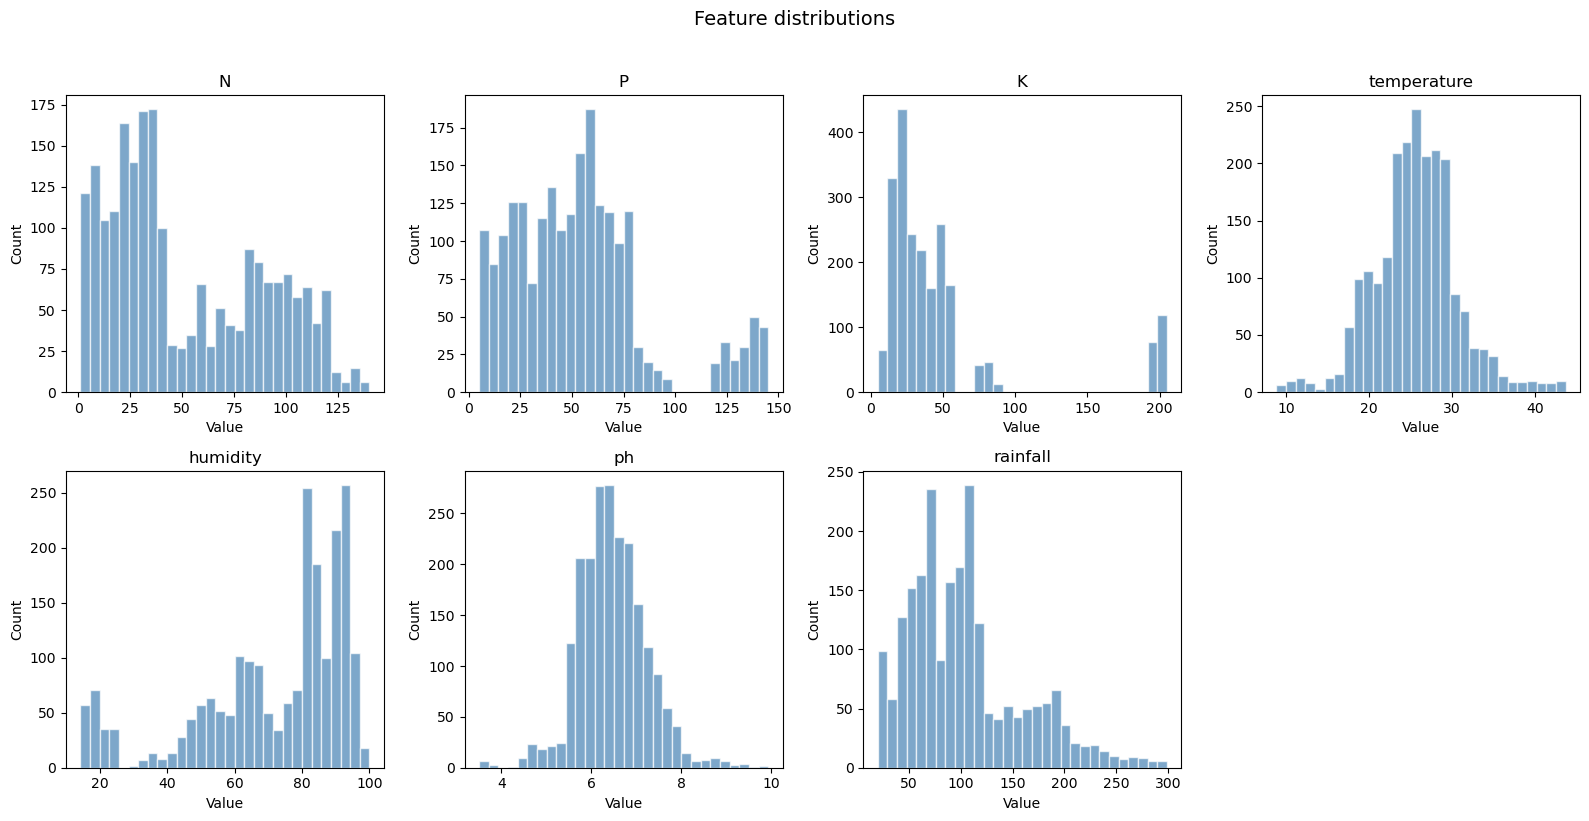

In [35]:
features = ['N','P','K','temperature','humidity','ph','rainfall']

fig, axes = plt.subplots(2,4, figsize=(16,8))
axes = axes.flatten()

for i,features in enumerate(features):
    axes[i].hist(df[features],bins=30, color='steelblue', alpha=0.7, edgecolor='white')
    axes[i].set_title(features,fontsize =12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)
plt.suptitle('Feature distributions', fontsize =14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/distributions.png', dpi=150)
plt.show()

Boxplot- feature per crop
(picking top 6 crops so its readable)

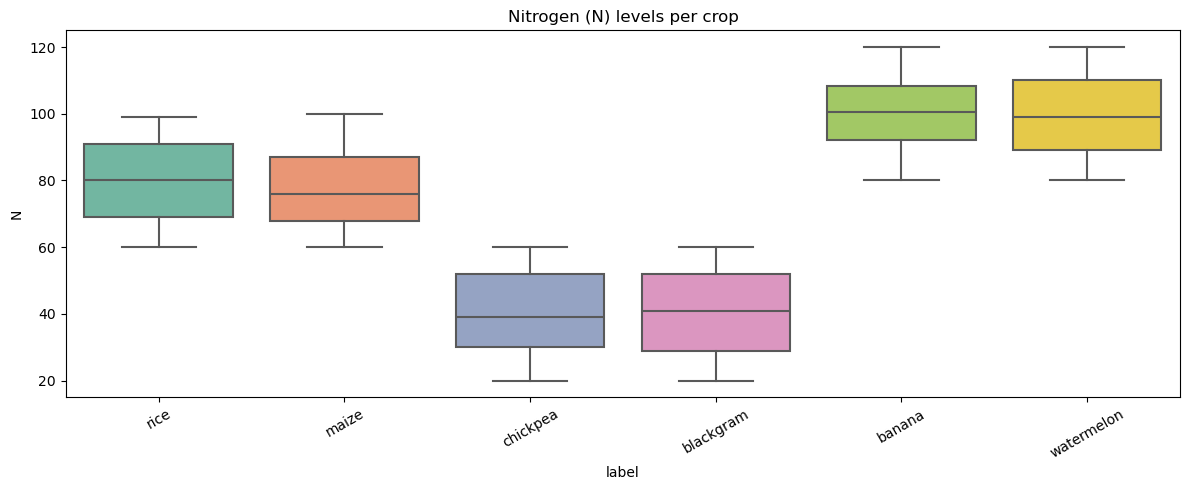

In [36]:
top_crops=df['label'].value_counts().head(6).index
df_top= df[df['label'].isin(top_crops)]

plt.figure(figsize=(12,5))
sns.boxplot(data=df_top, x ='label', y='N', palette='Set2')
plt.title('Nitrogen (N) levels per crop')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../outputs/boxplot_N.png', dpi = 120)
plt.show()

Pairplot of key features

In [37]:
# df_sample = df.sample(200, random_state=42)
# sns.pairplot(df_sample[['N','K','ph','rainfall','label']],
#             hue='label', plot_kws={'aplha': 0.5}, diag_kind='kde')
# plt.suptitle('Pairplot of key features', y= 1.02)
# plt.savefig('pairplot.png',dpi =120)
# plt.show()

Baseline models

In [38]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200, C=2.0, multi_class='auto')
lr.fit(X_train_sc,y_train)
print("LR Train accuracy:", round(lr.score(X_train_sc,y_train)*100,2), "%")
print("LR Test accuracy:", round(lr.score(X_test_sc,y_test)*100,2), "%")


LR Train accuracy: 97.81 %
LR Test accuracy: 96.78 %


train accuracy: 99.37 %
test accuracy: 98.85 %


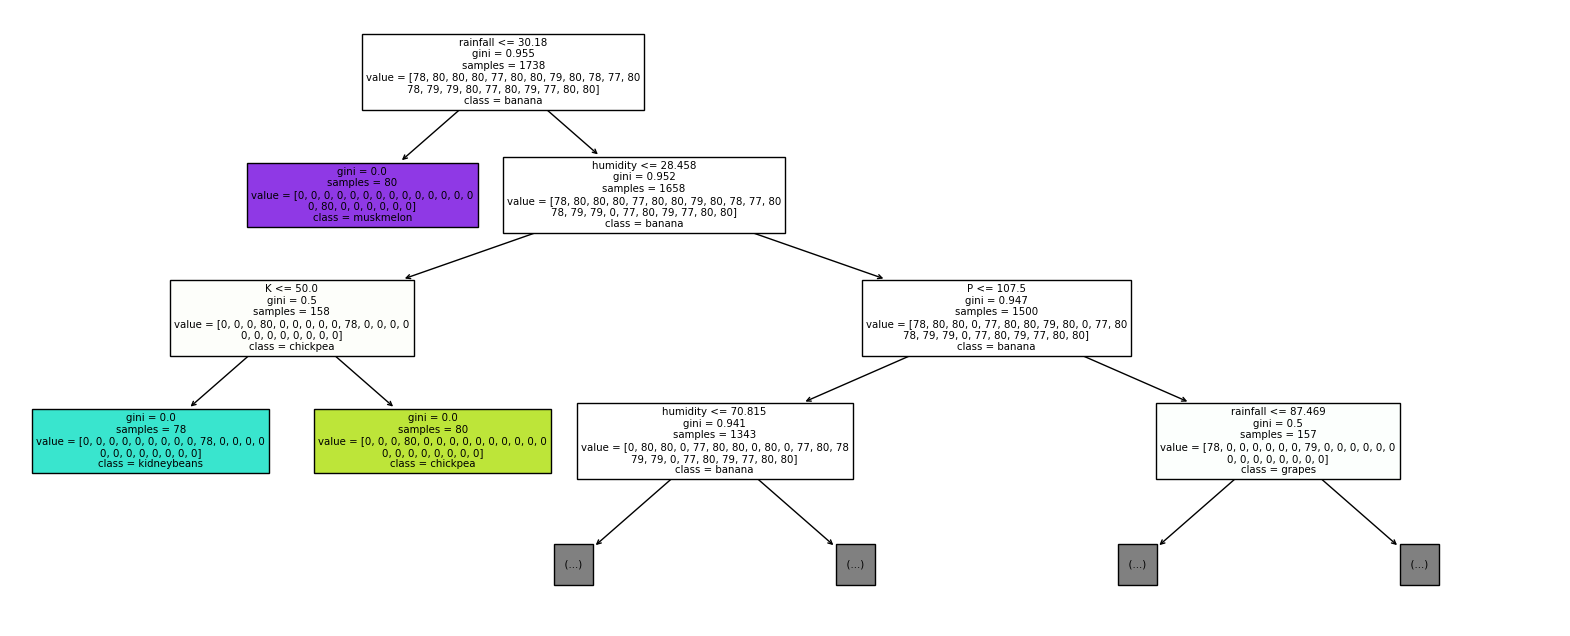

In [39]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=None,
    min_samples_leaf=5,
    criterion='gini',
    random_state=42
)

dt.fit(X_train_raw,y_train)   #no scaling needed for trees

print("train accuracy:", round(dt.score(X_train_raw,y_train)*100,2), "%")
print("test accuracy:", round(dt.score(X_test_raw,y_test)*100,2), "%")

feature_list=['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

from sklearn.tree import plot_tree
plt.figure(figsize=(20,8))
plot_tree(dt,max_depth=3,feature_names=feature_list,
        class_names=LE.classes_, filled=True)
plt.savefig("../outputs/decision_tree.png", dpi=100, bbox_inches='tight')
plt.show()


In [40]:
#dt won so saving it as baseline model
joblib.dump(dt,'../models/baseline_model.pkl')
print("saved : models/baseline_odel.pkl")

saved : models/baseline_odel.pkl


In [41]:
#quick sanity check- load and predict
loaded = joblib.load('../models/baseline_model.pkl')
sample = X_test_raw[:1]
print("Test prediction:", LE.inverse_transform(loaded.predict(sample)))

Test prediction: ['maize']


Evaluation metrics

In [42]:
from sklearn.metrics import (
    accuracy_score, 
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [43]:
# get predictions from both models
lr_pred= lr.predict(X_test_sc)
dt_pred= dt.predict(X_test_raw)

#Compare models
def evaluate_model(name, y_true, y_pred):
    print(f"\n{'='*40}")
    print(f"model: {name}")
    print(f"{'='*40}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, average='macro'):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred, average='macro'):.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=LE.classes_))

evaluate_model("LR", y_test,lr_pred)
evaluate_model("DT", y_test,dt_pred)




model: LR
Accuracy: 0.9678
Precision: 0.9694
Recall   : 0.9679
F1 Score : 0.9673

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        19
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.97        19
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.95      0.95      0.95        19
       maize       1.00      1.00      1.00        20
       mango       0.95      1.00      0.97        19
   mothbeans       0.94      0.75      0.83        20
    mungbean       0.95      1.00      0.98        20
   muskmelon       1.00      1.00      1.00        2

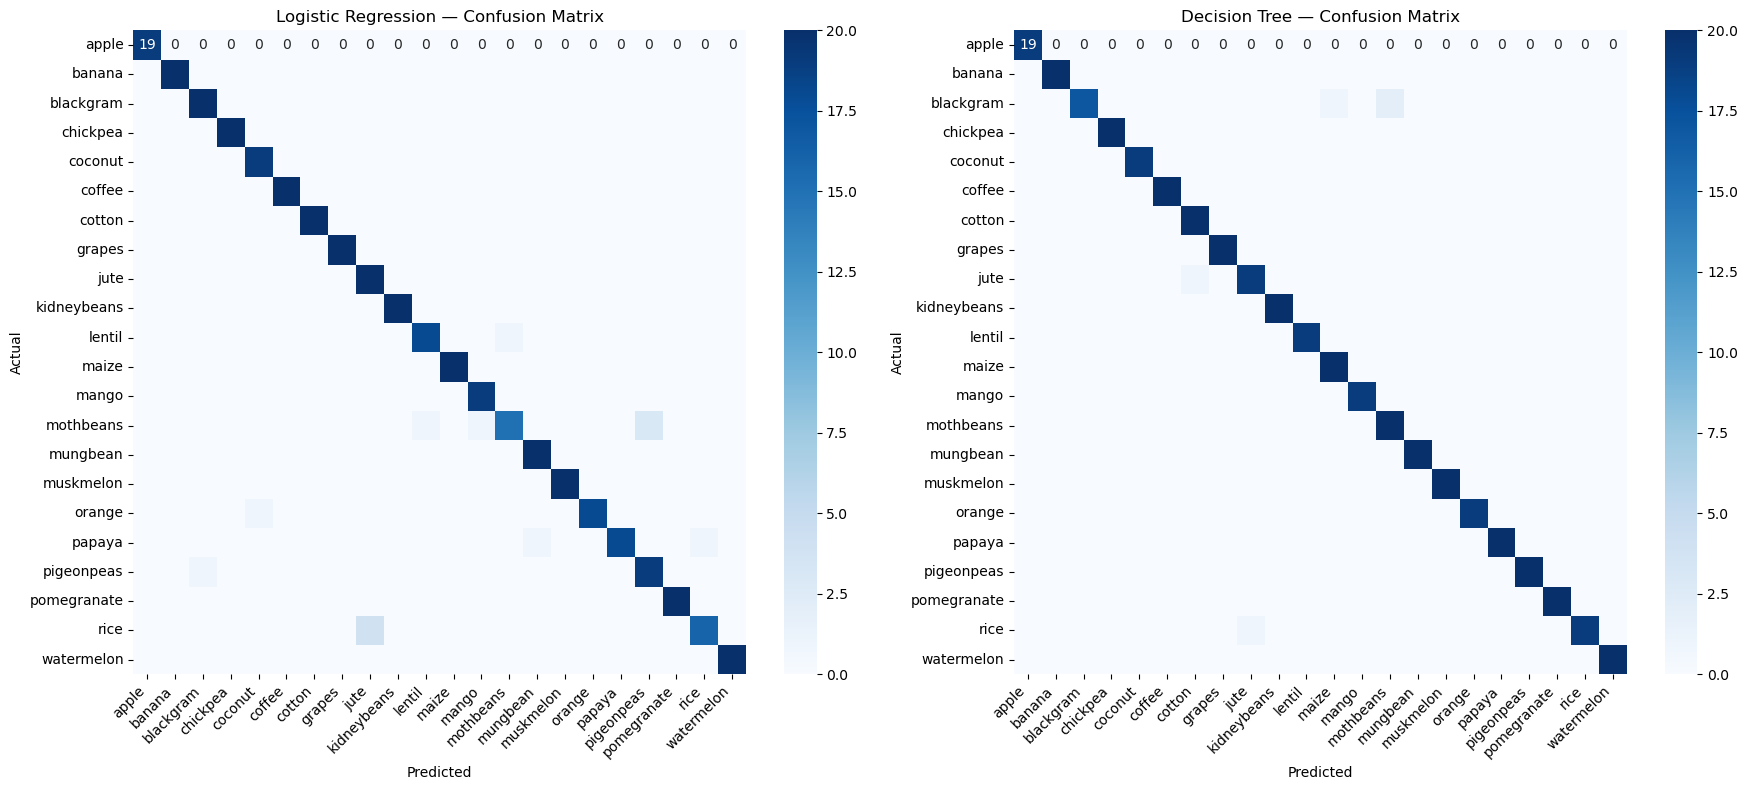

In [44]:
# confusion matrix heatmap
fig, axes= plt.subplots(1,2,figsize=(18,8))

for ax, preds, name in zip(axes, [lr_pred, dt_pred],
                            ["Logistic Regression", "Decision Tree"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LE.classes_,
                yticklabels=LE.classes_, ax=ax)
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../outputs/confusion_matrices.png', dpi=150)
plt.show()

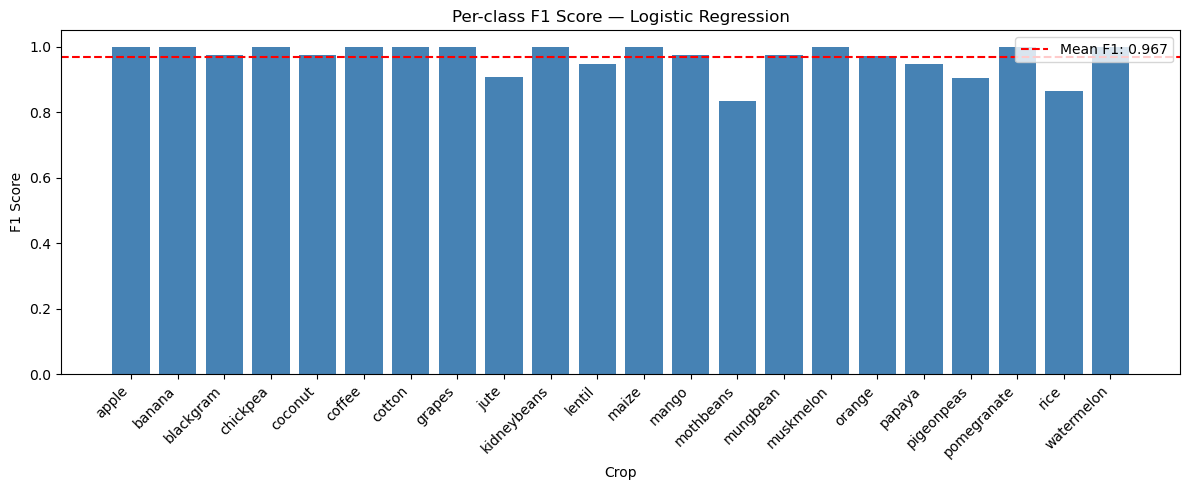

In [45]:
# per class F1 bar chart
f1_per_class = f1_score(y_test, lr_pred, average=None)
plt.figure(figsize=(12, 5))
bars = plt.bar(LE.classes_, f1_per_class, color='steelblue')
plt.axhline(y=f1_per_class.mean(), color='red',
            linestyle='--', label=f'Mean F1: {f1_per_class.mean():.3f}')
plt.xlabel('Crop')
plt.ylabel('F1 Score')
plt.title('Per-class F1 Score — Logistic Regression')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/per_class_f1.png', dpi=150)
plt.show()

In [46]:
#for quick load of models and return exact json , api will return
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    model  = joblib.load('../models/baseline_model.pkl')
    scaler = joblib.load('../models/scaler.pkl')
    le     = joblib.load('../models/label_encoder.pkl')

    X = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    pred = model.predict(X)   
    crop = le.inverse_transform(pred)[0]
    return {'crop': crop}

# Test it — rice conditions
rice_row = df[df['label'] == 'rice'].iloc[0]
print("Real rice values:", rice_row[feature_cols].values)
result = predict_crop(*rice_row[feature_cols].values)
print("Predicted:", result)


Real rice values: [90 42 43 20.87974371 82.00274423 6.502985292000001 202.9355362]
Predicted: {'crop': 'rice'}


#### ML Depth

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    max_depth=None,
    n_estimators=100,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1 #use all CPU cores
)

rf.fit(X_train_sc,y_train)

train_acc = rf.score(X_train_sc,y_train)*100
test_acc = rf.score(X_test_sc,y_test)*100

print(f"train accuracy:  {train_acc:.2f}")
print(f"test accuracy:  {test_acc:.2f}")
print(f"overfit gap: {(train_acc-test_acc):.2f}")

joblib.dump(rf, '../models/rf_model.pkl')

train accuracy:  100.00
test accuracy:  99.77
overfit gap: 0.23


['../models/rf_model.pkl']

cv mean: 0.9948 ± 0.0034


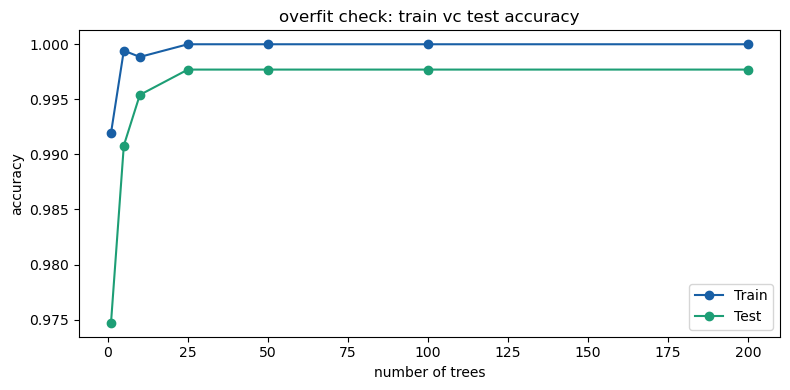

In [48]:
tree_counts = [1,5,10,25,50,100,200]
train_Scores, test_Scores= [],[]

for n in tree_counts:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train_sc,y_train)
    train_Scores.append(model.score(X_train_sc,y_train))
    test_Scores.append(model.score(X_test_sc,y_test))

plt.figure(figsize=(8,4))
plt.plot(tree_counts,train_Scores, 'o-', label='Train', color ='#185FA5')
plt.plot(tree_counts,test_Scores, 'o-', label='Test', color ='#1D9E75')
plt.xlabel("number of trees")
plt.ylabel("accuracy")
plt.title("overfit check: train vc test accuracy")
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/overfit_curve.png',dpi = 150)

from sklearn.model_selection import cross_val_score
cv_Scores = cross_val_score(rf, X_train_sc, y_train, cv = 5)
print(f"cv mean: {cv_Scores.mean():.4f} ± {cv_Scores.std():.4f}")

|--- humidity <= -1.93
|   |--- K <= 0.04
|   |   |--- class: 9.0
|   |--- K >  0.04
|   |   |--- class: 3.0
|--- humidity >  -1.93
|   |--- P <= 1.64
|   |   |--- K <= -0.67
|   |   |   |--- class: 16.0
|   |   |--- K >  -0.67
|   |   |   |--- humidity <= 0.11
|   |   |   |   |--- truncated branch of depth 11
|   |   |   |--- humidity >  0.11
|   |   |   |   |--- truncated branch of depth 11
|   |--- P >  1.64
|   |   |--- N <= -0.42
|   |   |   |--- humidity <= 0.69
|   |   |   |   |--- class: 7.0
|   |   |   |--- humidity >  0.69
|   |   |   |   |--- class: 0.0
|   |   |--- N >  -0.42
|   |   |   |--- temperature <= -0.27
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- temperature >  -0.27
|   |   |   |   |--- class: 7.0



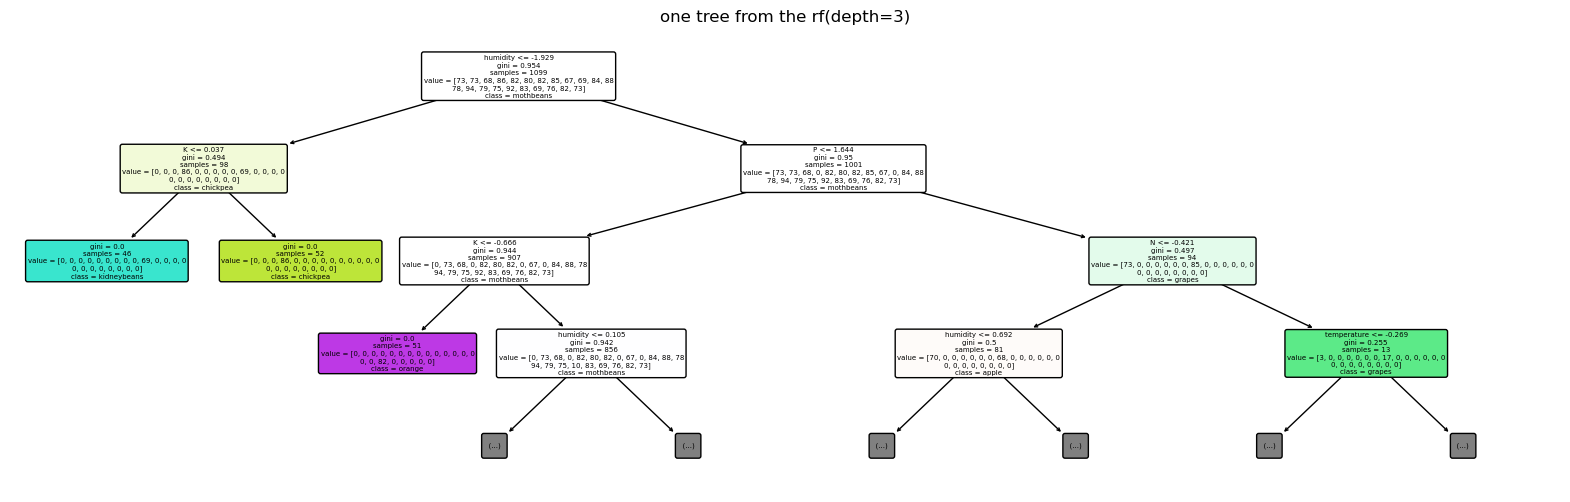

In [49]:
from sklearn.tree import export_text, plot_tree

feature_names= ['N','P','K','temperature','humidity','ph','rainfall' ]

single_tree = rf.estimators_[0]
print(export_text(single_tree,
                  feature_names=feature_names, max_depth=3))

fig,ax = plt.subplots(figsize =(20,6))
plot_tree(single_tree,feature_names=feature_names,
          class_names= LE.classes_,
          max_depth=3,
          filled=True,
          rounded=True,
          ax=ax)

plt.title("one tree from the rf(depth=3)")
plt.savefig("../outputs/one_tree.png", dpi=120, bbox_inches ='tight')

In [50]:
from xgboost import XGBClassifier

In [51]:
model = XGBClassifier()
print("ok")

ok


In [52]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0

)

xgb.fit(X_train_raw,y_train)

train_Acc = accuracy_score(y_train, xgb.predict(X_train_raw))
test_acc = accuracy_score(y_test, xgb.predict(X_test_raw))
print(f"train: {train_Acc:.4f} | test: {test_acc : .4f} | gap: { train_Acc-test_acc:.4f}")

print("\n Classification Report:")
print(classification_report(y_test, xgb.predict(X_test_raw),
                            target_names=LE.classes_))


train: 1.0000 | test:  1.0000 | gap: 0.0000

 Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        19
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        19
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       1.00      1.00      1.00        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        19
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange

Feature importance

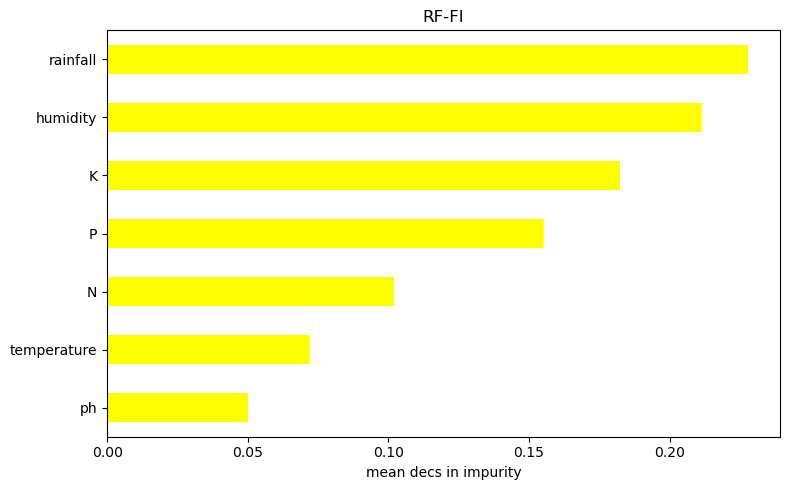

Top features:
rainfall       0.227878
humidity       0.211050
K              0.182359
P              0.154822
N              0.102117
temperature    0.071716
ph             0.050058
dtype: float64


In [ ]:
# random forest importance 
importances = pd.Series(rf.feature_importances_, index= feature_names)
importances_sorted = importances.sort_values(ascending = True)

plt.figure(figsize=(8,5))
importances_sorted.plot(kind = 'barh', color = "yellow")
plt.title("RF-FI")
plt.xlabel('mean decs in impurity')
plt.tight_layout()
plt.savefig('../outputs/rf_imp.png', dpi =150)
plt.show()

print('Top features:')
print(importances.sort_values(ascending = False))

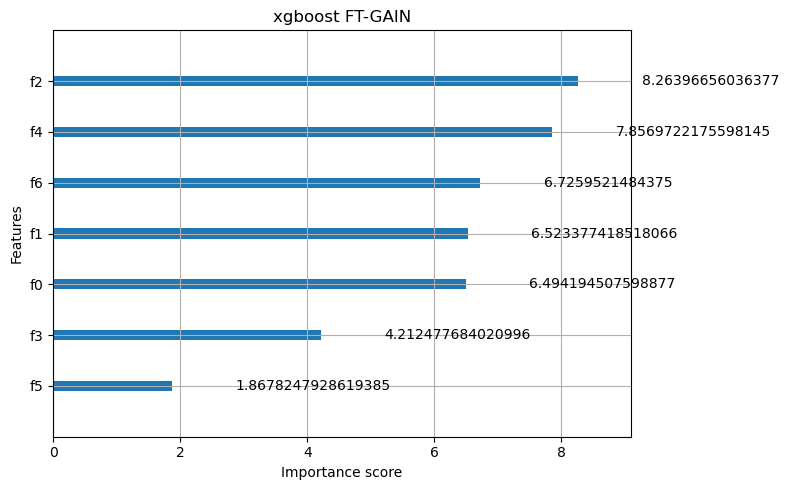

In [58]:
#  xgboost importance

from xgboost import plot_importance

fig,ax = plt.subplots(figsize =(8,5))
plot_importance(xgb, ax=ax,importance_type = 'gain',
                title='xgboost FT-GAIN')
plt.tight_layout()
plt.savefig('../outputs/xgb_imp.png',dpi=150)
plt.show()


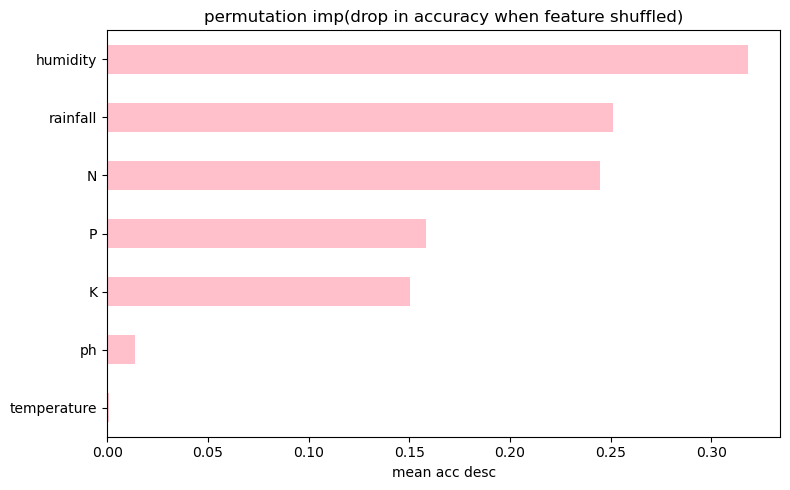

In [65]:
#  permutation importance (most reliable)
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf, X_test_sc, y_test,
    n_repeats= 10,  #shuffle each feature 10 times
    random_state= 42,
    n_jobs= 1
)

perm_imp = pd.Series(result.importances_mean,index= feature_names)
perm_imp_sorted = perm_imp.sort_values(ascending = True)

plt.figure(figsize=(8,5))
perm_imp_sorted.plot(kind='barh', color ='pink')
plt.title('permutation imp(drop in accuracy when feature shuffled)')
plt.xlabel('mean acc desc')
plt.tight_layout()
plt.savefig('../outputs/perm_imp.png', dpi =150)
plt.show()


In [78]:
#  drop weak features and retrain

threshold = 0.05 #drop features with imp below this

important_features = importances[importances> threshold].index.tolist()
print(f"keeping: {important_features}")
print(f"dropping : {[f for  f in feature_names if f not in important_features]}")

idx = [feature_names.index(f) for f  in important_features]
X_train_slim = X_train_sc[:,idx]
X_test_slim = X_test_sc[:,idx]

rf_slim = RandomForestClassifier(n_estimators=200, random_state=42)
rf_slim.fit(X_train_slim,y_train)

print(f"slim model acc: {rf_slim.score(X_test_slim, y_test):.4f}")


keeping: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
dropping : []
slim model acc: 0.9977
